In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Lendo conjunto de dados

In [2]:
df_participantes = pd.read_csv(
                    "data/2024/PARTICIPANTES_2024.csv",
                    sep=";",
                    encoding="latin1"
)

## Realizando amostragem 

In [3]:
n_amostra = 100_000

proporcao_uf = (
    df_participantes['SG_UF_PROVA']
    .value_counts(normalize=True)
)

n_por_uf = (
    proporcao_uf * n_amostra
).round().astype(int)

In [4]:
amostras = []

for uf, n in n_por_uf.items():

    df_uf = df_participantes[
        df_participantes['SG_UF_PROVA'] == uf
    ]

    amostra_uf = df_uf.sample(
        n=min(n, len(df_uf)),
        random_state=42
    )

    amostras.append(amostra_uf)

df_nacional_amostra = pd.concat(amostras)

In [5]:
df_nacional_amostra.shape

(99999, 38)

In [6]:
LIMIAR_BAIXA_RENDA = 706.00

In [7]:
faixas_renda = {
    "A": (0, 0),
    "B": (0, 1412),
    "C": (1412.01, 2118),
    "D": (2118.01, 2824),
    "E": (2824.01, 3530),
    "F": (3530.01, 4236),
    "G": (4236.01, 4942),
    "H": (4942.01, 7060),
    "I": (7060.01, 8472),
    "J": (8472.01, 9884),
    "K": (9884.01, 11296),
    "L": (11296.01, 12708),
    "M": (12708.01, 14120),
    "N": (14120.01, 16944),
    "O": (16944.01, 21180),
    "P": (21180.01, 28240),
    "Q": (28240.01, np.inf)
}

In [8]:
renda_media = {}

for faixa, (limite_inferior, limite_superior) in faixas_renda.items():
    if np.isfinite(limite_superior):
        renda_media[faixa] = (limite_inferior + limite_superior) / 2
    else:
        renda_media[faixa] = np.nan

In [9]:
df_nacional_amostra["RENDA_FAMILIAR_EST"] = (df_nacional_amostra["Q007"].map(renda_media))
df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST
2701768,210064828516,2024,14,F,3,1,1,1,18,NaN,0,3550308,São Paulo,35,SP,C,E,C,D,3,A,D,A,C,C,B,A,B,A,B,B,B,B,B,B,C,D,D,2471.005
3786534,210065937571,2024,2,F,1,3,1,2,0,1.0,0,3557006,Votorantim,35,SP,G,E,D,B,4,A,K,A,D,D,B,A,B,B,B,B,B,D,A,B,B,E,B,10590.005
3460263,210065604069,2024,8,F,1,3,1,1,6,NaN,0,3504503,Avaré,35,SP,B,B,C,B,2,B,E,A,B,B,B,A,B,A,A,B,A,B,A,B,B,C,C,3177.005
4229854,210066392206,2024,3,F,1,3,1,2,0,1.0,0,3541000,Praia Grande,35,SP,B,D,B,B,5,A,C,A,B,C,B,B,B,A,B,B,A,C,A,B,B,E,A,1765.005
3353725,210065494947,2024,3,F,1,1,1,2,0,1.0,0,3507506,Botucatu,35,SP,C,E,C,B,7,A,B,A,B,C,B,A,B,A,A,A,A,B,A,A,A,C,A,706.000


In [10]:
df_nacional_amostra["RENDA_PER_CAP_EST"] = np.where(
    df_nacional_amostra["Q005"] > 0,
    df_nacional_amostra["RENDA_FAMILIAR_EST"] / df_nacional_amostra["Q005"],
    np.nan
)
df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST
2701768,210064828516,2024,14,F,3,1,1,1,18,NaN,0,3550308,São Paulo,35,SP,C,E,C,D,3,A,D,A,C,C,B,A,B,A,B,B,B,B,B,B,C,D,D,2471.005,823.668333
3786534,210065937571,2024,2,F,1,3,1,2,0,1.0,0,3557006,Votorantim,35,SP,G,E,D,B,4,A,K,A,D,D,B,A,B,B,B,B,B,D,A,B,B,E,B,10590.005,2647.501250
3460263,210065604069,2024,8,F,1,3,1,1,6,NaN,0,3504503,Avaré,35,SP,B,B,C,B,2,B,E,A,B,B,B,A,B,A,A,B,A,B,A,B,B,C,C,3177.005,1588.502500
4229854,210066392206,2024,3,F,1,3,1,2,0,1.0,0,3541000,Praia Grande,35,SP,B,D,B,B,5,A,C,A,B,C,B,B,B,A,B,B,A,C,A,B,B,E,A,1765.005,353.001000
3353725,210065494947,2024,3,F,1,1,1,2,0,1.0,0,3507506,Botucatu,35,SP,C,E,C,B,7,A,B,A,B,C,B,A,B,A,A,A,A,B,A,A,A,C,A,706.000,100.857143


In [11]:
df_nacional_amostra["BAIXA_RENDA_EST"] = np.select(
    [
        df_nacional_amostra["RENDA_PER_CAP_EST"].isna(),
        df_nacional_amostra["RENDA_PER_CAP_EST"] <= 706
    ],
    [
        None,
        "Sim"
    ],
    default="Nao"
)

df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2701768,210064828516,2024,14,F,3,1,1,1,18,NaN,0,3550308,São Paulo,35,SP,C,E,C,D,3,A,D,A,C,C,B,A,B,A,B,B,B,B,B,B,C,D,D,2471.005,823.668333,Nao
3786534,210065937571,2024,2,F,1,3,1,2,0,1.0,0,3557006,Votorantim,35,SP,G,E,D,B,4,A,K,A,D,D,B,A,B,B,B,B,B,D,A,B,B,E,B,10590.005,2647.501250,Nao
3460263,210065604069,2024,8,F,1,3,1,1,6,NaN,0,3504503,Avaré,35,SP,B,B,C,B,2,B,E,A,B,B,B,A,B,A,A,B,A,B,A,B,B,C,C,3177.005,1588.502500,Nao
4229854,210066392206,2024,3,F,1,3,1,2,0,1.0,0,3541000,Praia Grande,35,SP,B,D,B,B,5,A,C,A,B,C,B,B,B,A,B,B,A,C,A,B,B,E,A,1765.005,353.001000,Sim
3353725,210065494947,2024,3,F,1,1,1,2,0,1.0,0,3507506,Botucatu,35,SP,C,E,C,B,7,A,B,A,B,C,B,A,B,A,A,A,A,B,A,A,A,C,A,706.000,100.857143,Sim


In [12]:
df_nacional_amostra[df_nacional_amostra["BAIXA_RENDA_EST"] == None]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST


In [13]:
df_nacional_amostra[
    ["Q005", "Q007", "RENDA_FAMILIAR_EST", "RENDA_PER_CAP_EST", "BAIXA_RENDA_EST"]
].head()

,Q005,Q007,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2701768,3,D,2471.005,823.668333,Nao
3786534,4,K,10590.005,2647.501250,Nao
3460263,2,E,3177.005,1588.502500,Nao
4229854,5,C,1765.005,353.001000,Sim
3353725,7,B,706.000,100.857143,Sim


In [14]:
df_nacional_amostra["BAIXA_RENDA_EST"].value_counts(dropna=False)

BAIXA_RENDA_EST
Sim    62197
Nao    36381
NaN     1421
Name: count, dtype: int64

In [15]:
df_nacional_amostra["Q007"].value_counts(dropna=False).sort_index()

Q007
A     9070
B    33072
C    17396
D     7599
E     7165
F     5265
G     4930
H     4080
I     1890
J     1425
K     1848
L      841
M      925
N      998
O     1240
P      834
Q     1421
Name: count, dtype: int64

In [16]:
df_nacional_amostra[df_nacional_amostra["BAIXA_RENDA_EST"] == 'Nao']

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2701768,210064828516,2024,14,F,3,1,1,1,18,NaN,0,3550308,São Paulo,35,SP,C,E,C,D,3,A,D,A,C,C,B,A,B,A,B,B,B,B,B,B,C,D,D,2471.005,823.668333,Nao
3786534,210065937571,2024,2,F,1,3,1,2,0,1.0,0,3557006,Votorantim,35,SP,G,E,D,B,4,A,K,A,D,D,B,A,B,B,B,B,B,D,A,B,B,E,B,10590.005,2647.501250,Nao
3460263,210065604069,2024,8,F,1,3,1,1,6,NaN,0,3504503,Avaré,35,SP,B,B,C,B,2,B,E,A,B,B,B,A,B,A,A,B,A,B,A,B,B,C,C,3177.005,1588.502500,Nao
239129,210062309331,2024,12,F,0,1,1,2,0,NaN,0,3506102,Bebedouro,35,SP,H,H,A,B,3,B,I,A,B,C,B,A,B,A,B,A,A,B,A,B,A,D,A,7766.005,2588.668333,Nao
3831241,210065983233,2024,5,M,1,1,1,1,3,NaN,0,3548500,Santos,35,SP,G,G,D,E,2,A,M,B,D,D,B,A,C,A,B,B,B,D,A,B,C,C,D,13414.005,6707.002500,Nao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116514,210062185397,2024,15,M,2,3,1,1,18,NaN,0,1400100,Boa Vista,14,RR,A,B,B,B,3,B,D,A,C,C,B,A,B,A,A,A,A,B,A,A,B,B,A,2471.005,823.668333,Nao
4248753,210066411108,2024,2,M,1,3,1,3,0,NaN,1,1400100,Boa Vista,14,RR,F,F,E,E,3,A,O,A,B,D,C,A,B,A,B,B,B,D,A,B,D,E,E,19062.005,6354.001667,Nao
590383,210062669886,2024,2,M,1,3,1,3,0,NaN,1,1400308,Mucajaí,14,RR,F,D,A,A,3,A,E,A,B,C,B,A,B,B,B,B,B,C,A,B,A,D,A,3177.005,1059.001667,Nao
2983383,210065117183,2024,6,M,1,1,1,1,3,NaN,0,1400100,Boa Vista,14,RR,F,G,D,D,3,A,K,A,D,D,B,A,B,A,B,B,B,D,A,B,B,E,A,10590.005,3530.001667,Nao


## Qual foi o desempenho dos estudantes que realizaram o exame no Brasil?

### Lendo o conjunto de dados de resultados

In [17]:
df_resultados = pd.read_csv(
                './data/2024/RESULTADOS_2024.csv',
                sep=";",
                encoding="latin1"
                )

## Realizando amostragem

Nos microdados do ENEM 2024, os arquivos de participantes e resultados não possuem uma chave identificadora comum que permita vincular individualmente as informações socioeconômicas às notas. Dessa forma, as análises de perfil dos participantes e de desempenho acadêmico foram realizadas separadamente.

In [18]:
proporcao_uf_resultados = (
    df_resultados['SG_UF_PROVA']
    .value_counts(normalize=True)
)

In [19]:
N_AMOSTRA_RESULTADOS = 100_000

n_por_uf_resultados = (
    proporcao_uf_resultados * N_AMOSTRA_RESULTADOS
).round().astype(int)

In [20]:
amostras_resultados = []

for uf, n in n_por_uf_resultados.items():

    df_uf = df_resultados[
        df_resultados['SG_UF_PROVA'] == uf
    ]

    amostra_uf = df_uf.sample(
        n=n,
        random_state=42
    )

    amostras_resultados.append(amostra_uf)

df_nacional_resultados = pd.concat(
    amostras_resultados,
    ignore_index=True
)

In [21]:
df_nacional_resultados.shape

(99999, 42)

In [22]:
areas = {
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_LC': 'Linguagens e Códigos',
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_REDACAO': 'Redação'
}

estatisticas = df_nacional_resultados[
    list(areas.keys())
].describe().T

estatisticas.index = estatisticas.index.map(areas)

estatisticas

,count,mean,std,min,25%,50%,75%,max
Ciências da Natureza,69371.0,493.605557,78.783895,0.0,431.4,488.2,549.6,853.9
Ciências Humanas,73117.0,510.604959,93.016254,0.0,445.8,515.9,575.8,819.7
Linguagens e Códigos,73117.0,524.147680,69.774386,0.0,484.2,531.1,571.6,795.8
Matemática,69371.0,526.813898,114.213738,0.0,430.9,498.7,611.1,961.9
Redação,73117.0,624.336885,215.809664,0.0,520.0,640.0,780.0,980.0


In [23]:
estatisticas = (
    df_nacional_resultados[list(areas.keys())]
    .describe()
    .T
    .rename(columns={
        'count': 'N',
        'mean': 'Média',
        'std': 'Desvio-padrão',
        'min': 'Mínimo',
        '25%': 'Q1',
        '50%': 'Mediana',
        '75%': 'Q3',
        'max': 'Máximo'
    })
)

estatisticas.index = estatisticas.index.map(areas)

estatisticas

,N,Média,Desvio-padrão,Mínimo,Q1,Mediana,Q3,Máximo
Ciências da Natureza,69371.0,493.605557,78.783895,0.0,431.4,488.2,549.6,853.9
Ciências Humanas,73117.0,510.604959,93.016254,0.0,445.8,515.9,575.8,819.7
Linguagens e Códigos,73117.0,524.147680,69.774386,0.0,484.2,531.1,571.6,795.8
Matemática,69371.0,526.813898,114.213738,0.0,430.9,498.7,611.1,961.9
Redação,73117.0,624.336885,215.809664,0.0,520.0,640.0,780.0,980.0


## Distribuição das Notas nas 5 Áreas de Conhecimento
### Histogramas

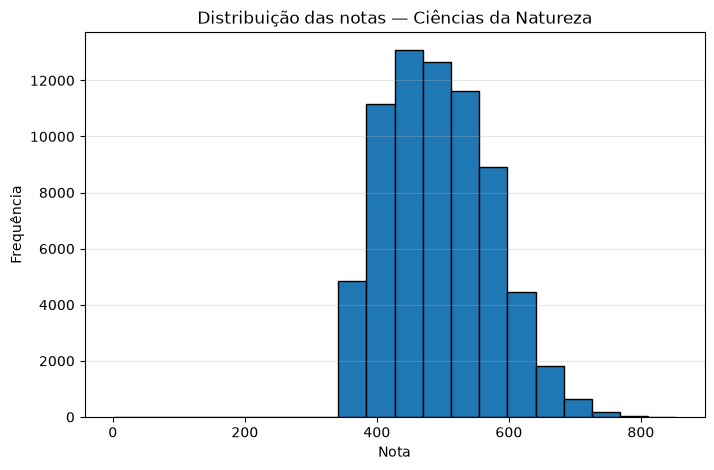

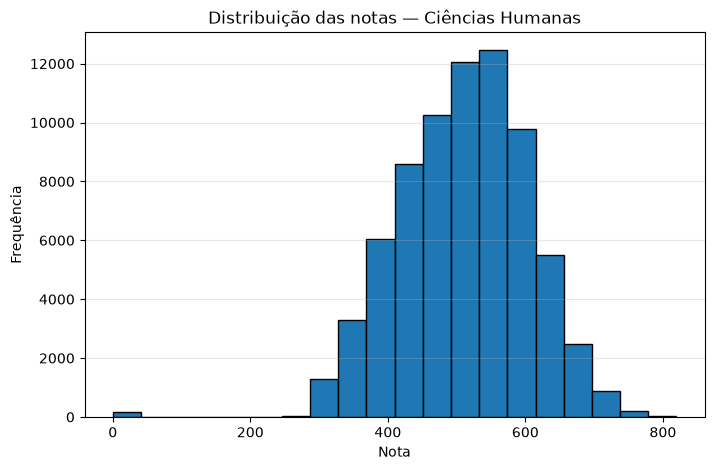

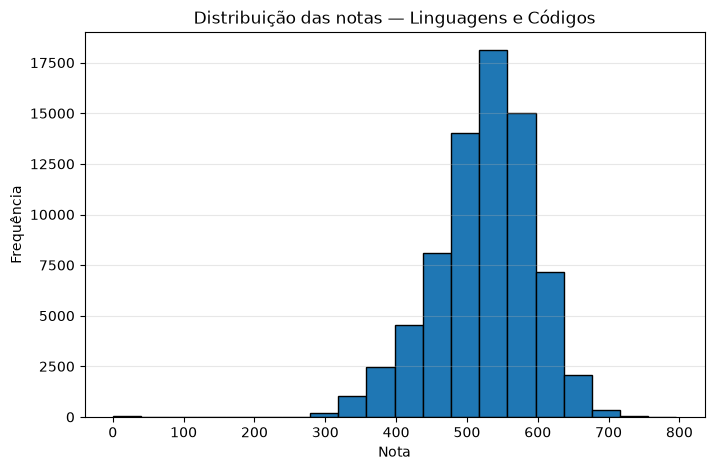

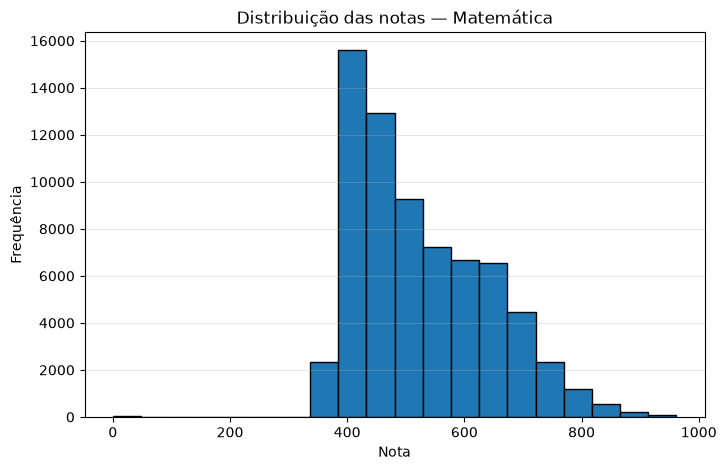

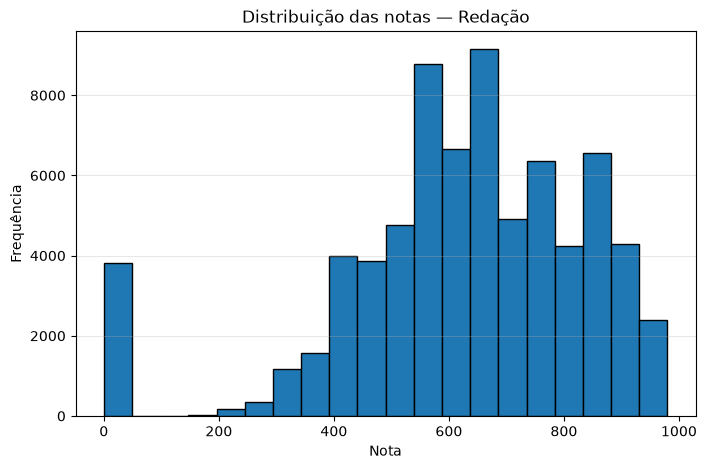

In [24]:
for coluna, nome in areas.items():
    dados = df_nacional_resultados[coluna].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(dados, bins=20, edgecolor='black')

    plt.title(f'Distribuição das notas — {nome}')
    plt.xlabel('Nota')
    plt.ylabel('Frequência')

    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Boxplots

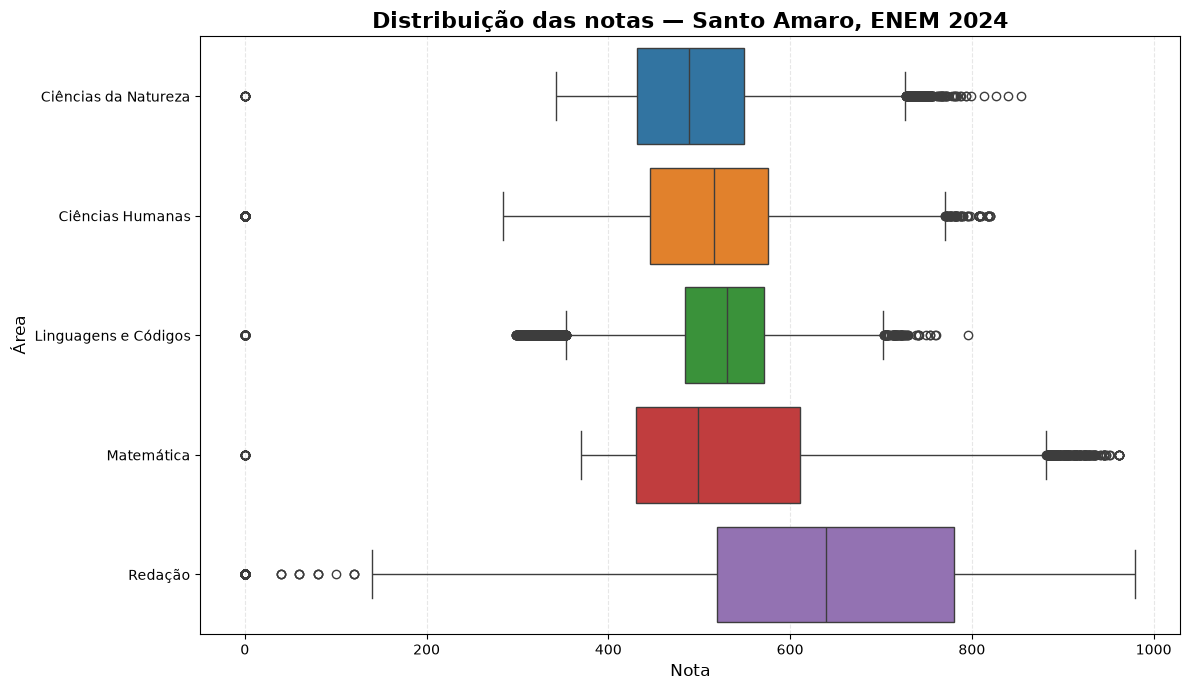

In [25]:

dados_boxplot = df_nacional_resultados[
    list(areas.keys())
].rename(columns=areas)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=dados_boxplot,
    orient='h'
)

plt.title(
    'Distribuição das notas — Santo Amaro, ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Nota', fontsize=12)
plt.ylabel('Área', fontsize=12)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

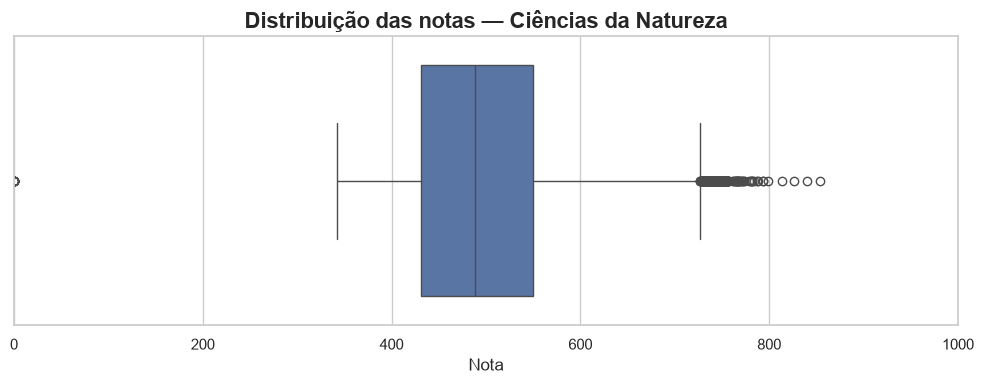

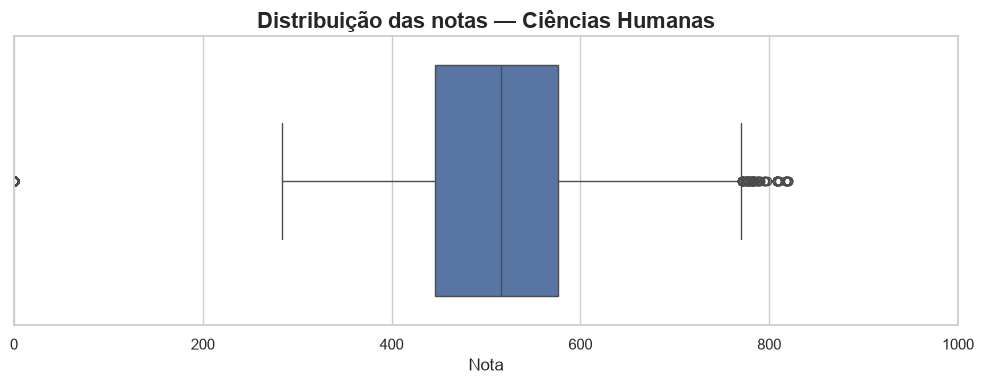

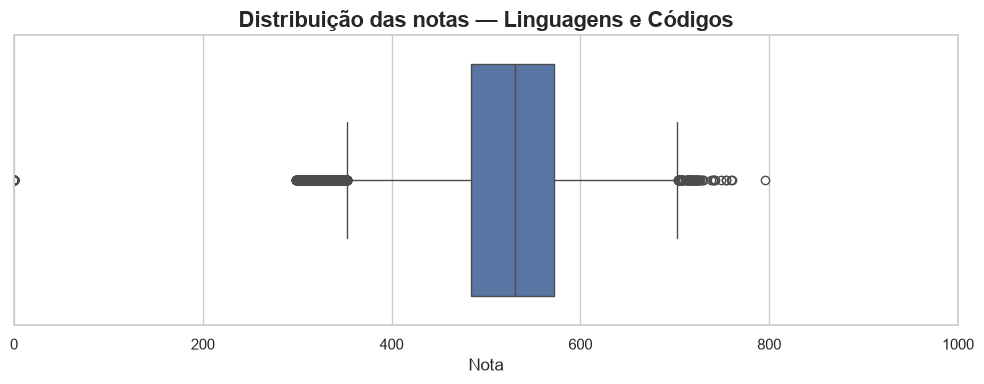

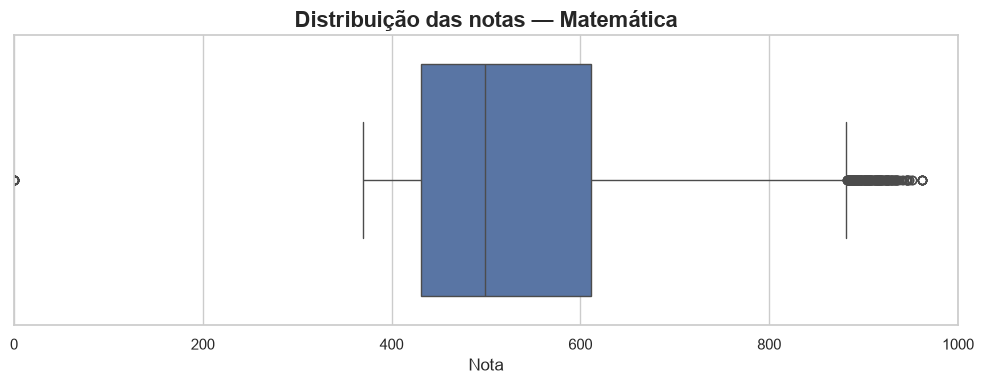

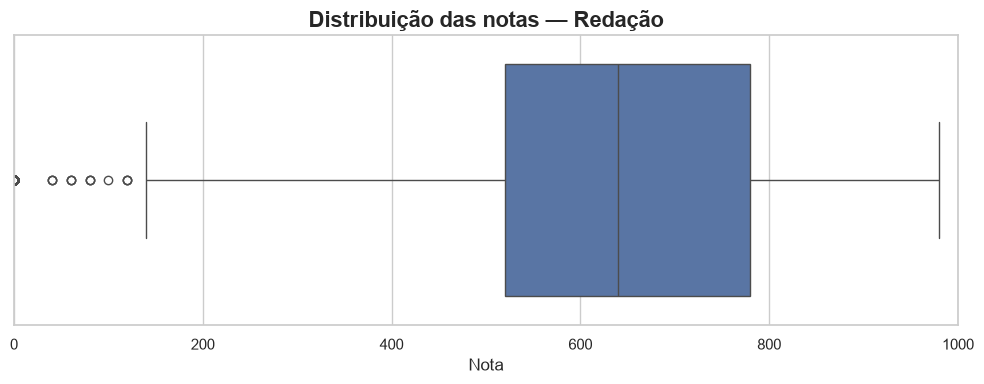

In [26]:
sns.set_theme(style="whitegrid")

for coluna, nome in areas.items():

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df_nacional_resultados[coluna],
        orient='h'
    )

    plt.title(
        f'Distribuição das notas — {nome}',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Nota', fontsize=12)

    plt.xlim(0, 1000)

    plt.tight_layout()
    plt.show()

## Distribuição dos Participantes por Renda Familiar

In [27]:
renda_familiar = (
    df_nacional_amostra['Q007']
    .value_counts()
    .sort_index()
)

renda_familiar

Q007
A     9070
B    33072
C    17396
D     7599
E     7165
F     5265
G     4930
H     4080
I     1890
J     1425
K     1848
L      841
M      925
N      998
O     1240
P      834
Q     1421
Name: count, dtype: int64

In [28]:
percentuais_renda = (
    df_nacional_amostra['Q007']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

percentuais_renda

Q007
A     9.070091
B    33.072331
C    17.396174
D     7.599076
E     7.165072
F     5.265053
G     4.930049
H     4.080041
I     1.890019
J     1.425014
K     1.848018
L     0.841008
M     0.925009
N     0.998010
O     1.240012
P     0.834008
Q     1.421014
Name: proportion, dtype: float64

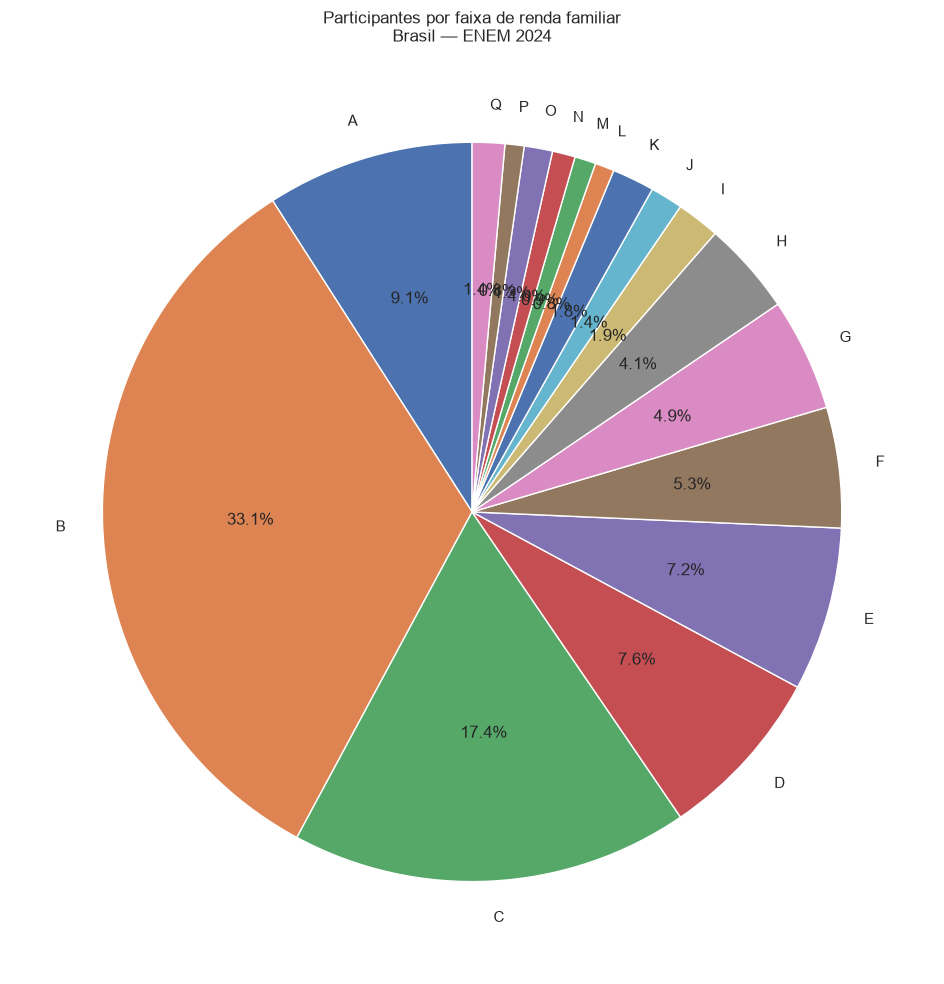

In [29]:
renda_familiar = (
    df_nacional_amostra['Q007']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 10))

plt.pie(
    renda_familiar,
    labels=renda_familiar.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2024'
)

plt.tight_layout()
plt.show()

In [30]:
# Agrupamento das categorias oficiais do Q007
grupos_renda = {
    'Sem renda': ['A'],
    'Até 1,5 SM': ['B', 'C'],
    'De 1,5 a 3 SM': ['D', 'E', 'F'],
    'De 3 a 6 SM': ['G', 'H', 'I'],
    'De 6 a 10 SM': ['J', 'K', 'L', 'M'],
    'Acima de 10 SM': ['N', 'O', 'P', 'Q']
}

# Cria um dicionário categoria Q007 -> grupo
mapa_renda = {
    categoria: grupo
    for grupo, categorias in grupos_renda.items()
    for categoria in categorias
}

# Cria a nova coluna
df_nacional_amostra['GRUPO_RENDA'] = df_nacional_amostra['Q007'].map(mapa_renda)

# Frequência dos grupos
distribuicao_renda = (
    df_nacional_amostra['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

distribuicao_renda

GRUPO_RENDA
Sem renda          9070
Até 1,5 SM        50468
De 1,5 a 3 SM     20029
De 3 a 6 SM       10900
De 6 a 10 SM       5039
Acima de 10 SM     4493
Name: count, dtype: int64

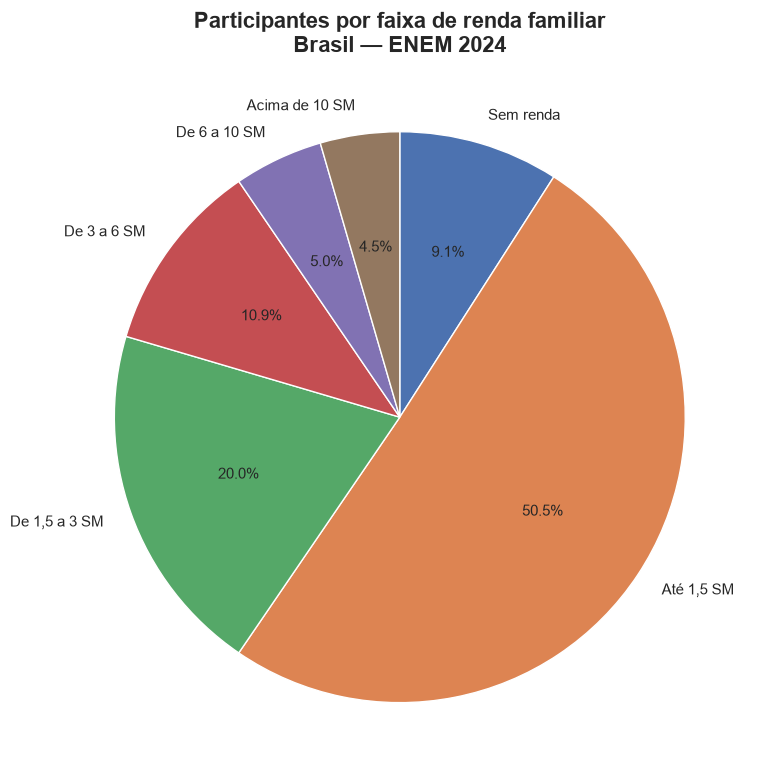

In [31]:
plt.figure(figsize=(10, 8))

plt.pie(
    distribuicao_renda,
    labels=distribuicao_renda.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

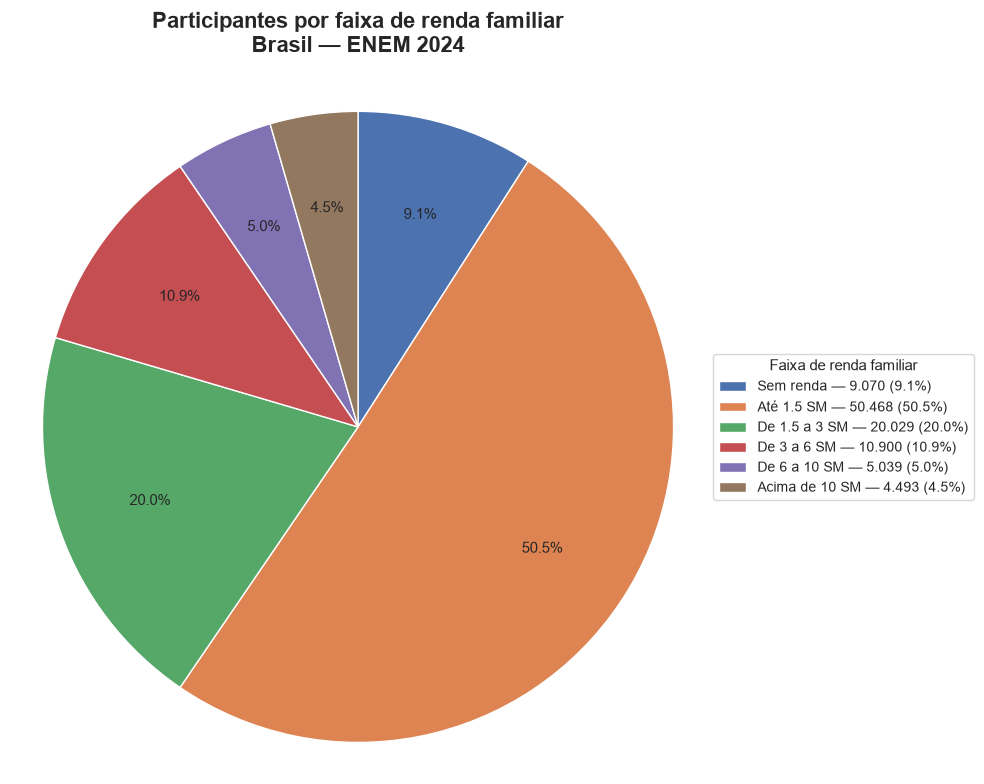

In [32]:
# Frequência dos grupos
distribuicao_renda = (
    df_nacional_amostra['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

total = distribuicao_renda.sum()

# Percentuais
percentuais = distribuicao_renda / total * 100

# Texto da legenda
legenda = [
    f'{grupo} — {valor:,} ({percentual:.1f}%)'.replace(',', '.')
    for grupo, valor, percentual
    in zip(
        distribuicao_renda.index,
        distribuicao_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(
    distribuicao_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Faixa de renda familiar',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

## Participação dos Estudantes de Baixa Renda

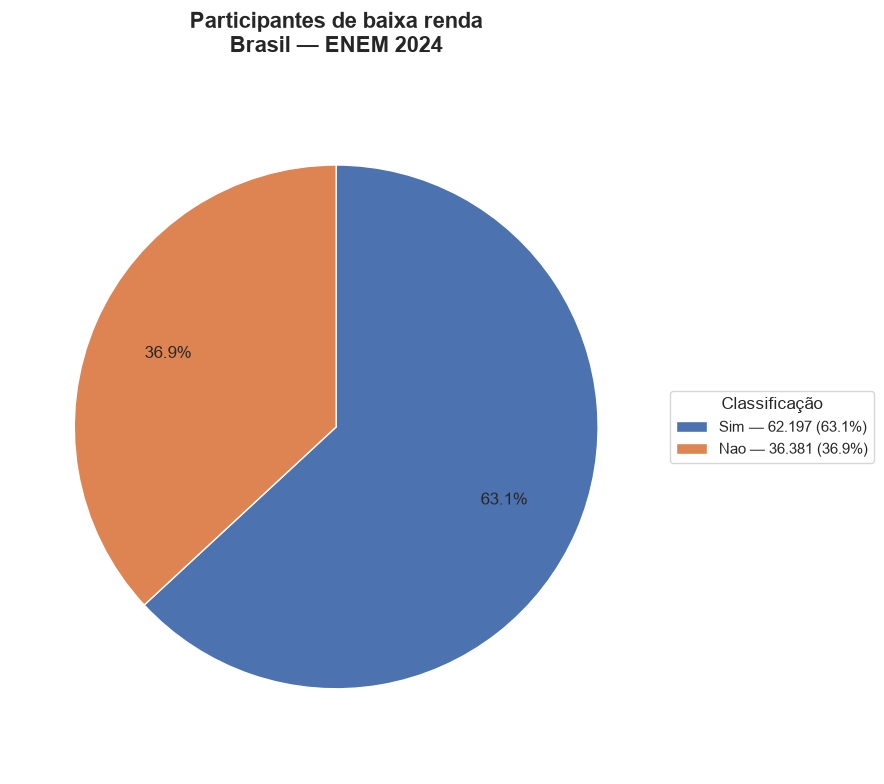

In [33]:
distribuicao_baixa_renda = (
    df_nacional_amostra['BAIXA_RENDA_EST']
    .dropna()
    .value_counts()
    .reindex(['Sim', 'Nao'], fill_value=0)
)

total = distribuicao_baixa_renda.sum()

percentuais = distribuicao_baixa_renda / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_baixa_renda.index,
        distribuicao_baixa_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_baixa_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes de baixa renda\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

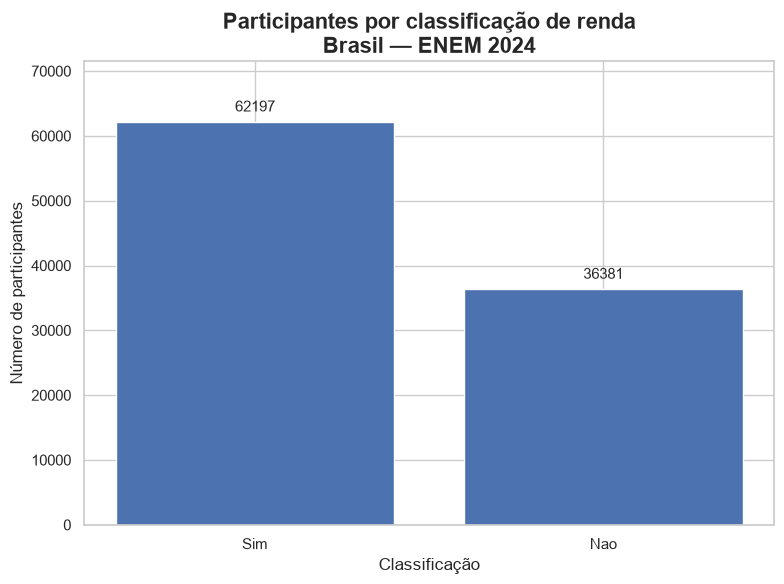

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_baixa_renda.index,
    distribuicao_baixa_renda.values
)

ax.set_title(
    'Participantes por classificação de renda\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

# Mostra o valor sobre cada barra
ax.bar_label(
    barras,
    fmt='%d',
    padding=5,
    fontsize=11
)

ax.set_ylim(
    0,
    distribuicao_baixa_renda.max() * 1.15
)

plt.tight_layout()
plt.show()

## Distribuição dos Participantes por Sexo Biológico

In [35]:
df_nacional_amostra['TP_SEXO'].value_counts(dropna=False)

TP_SEXO
F    60479
M    39520
Name: count, dtype: int64

In [36]:
distribuicao_sexo = (
    df_nacional_amostra['TP_SEXO']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)
distribuicao_sexo

TP_SEXO
F    60.48
M    39.52
Name: proportion, dtype: float64

In [37]:
nomes_sexo = {
    'M': 'Masculino',
    'F': 'Feminino'
}

distribuicao_sexo.index = distribuicao_sexo.index.map(nomes_sexo)

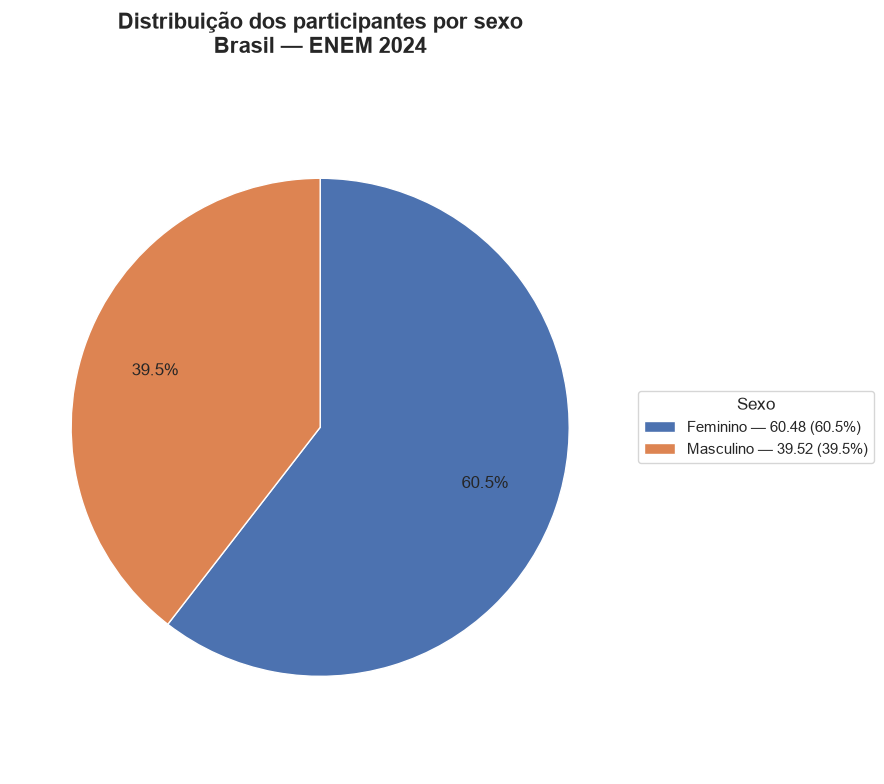

In [38]:

total = distribuicao_sexo.sum()

percentuais = distribuicao_sexo / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_sexo.index,
        distribuicao_sexo.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_sexo,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Sexo',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Distribuição dos participantes por sexo\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

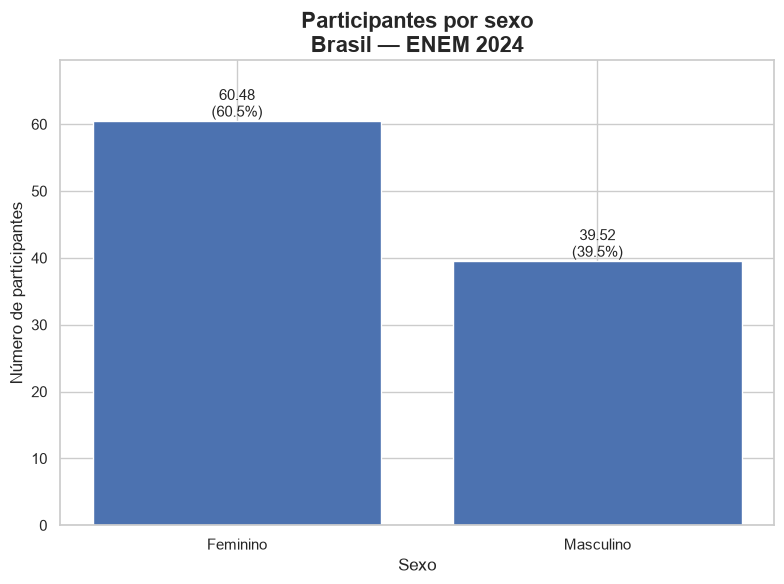

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_sexo.index,
    distribuicao_sexo.values
)

for barra, valor in zip(barras, distribuicao_sexo.values):
    percentual = valor / total * 100
    
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{valor:,}\n({percentual:.1f}%)'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_title(
    'Participantes por sexo\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

ax.set_ylim(0, distribuicao_sexo.max() * 1.15)

plt.tight_layout()
plt.show()

## Participação dos Candidatos Negros e Pardos

In [40]:
df_nacional_amostra['TP_COR_RACA'].value_counts(dropna=False)

TP_COR_RACA
3    42918
1    41229
2    12514
4     1452
0     1176
5      710
Name: count, dtype: int64

In [41]:
cor_raca = (
    df_nacional_amostra['TP_COR_RACA']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

cor_raca

TP_COR_RACA
3    42.92
1    41.23
2    12.51
4     1.45
0     1.18
5     0.71
Name: proportion, dtype: float64

In [42]:
mapa_cor_raca = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
}

df_nacional_amostra['COR_RACA'] = (
    df_nacional_amostra['TP_COR_RACA']
    .map(mapa_cor_raca)
)

In [43]:
df_nacional_amostra['TP_COR_RACA'].value_counts(normalize=True).mul(100).sort_index()

TP_COR_RACA
0     1.176012
1    41.229412
2    12.514125
3    42.918429
4     1.452015
5     0.710007
Name: proportion, dtype: float64

In [44]:
df_nacional_amostra['GRUPO_RACIAL'] = (
    df_nacional_amostra['TP_COR_RACA']
    .map({
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena',
        6: 'Não dispõe da informação'
    })
)

In [45]:
df_nacional_amostra['GRUPO_RACIAL'].value_counts()

GRUPO_RACIAL
Parda            42918
Branca           41229
Preta            12514
Amarela           1452
Não declarado     1176
Indígena           710
Name: count, dtype: int64

In [46]:
df_nacional_amostra['NEGRO'] = (
    df_nacional_amostra['TP_COR_RACA']
    .isin([2, 3])
    .map({
        True: 'Preta ou Parda',
        False: 'Demais categorias'
    })
)

In [47]:
distribuicao_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts()
)

distribuicao_negros

NEGRO
Preta ou Parda       55432
Demais categorias    44567
Name: count, dtype: int64

In [48]:
percentuais_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentuais_negros

NEGRO
Preta ou Parda       55.43
Demais categorias    44.57
Name: proportion, dtype: float64

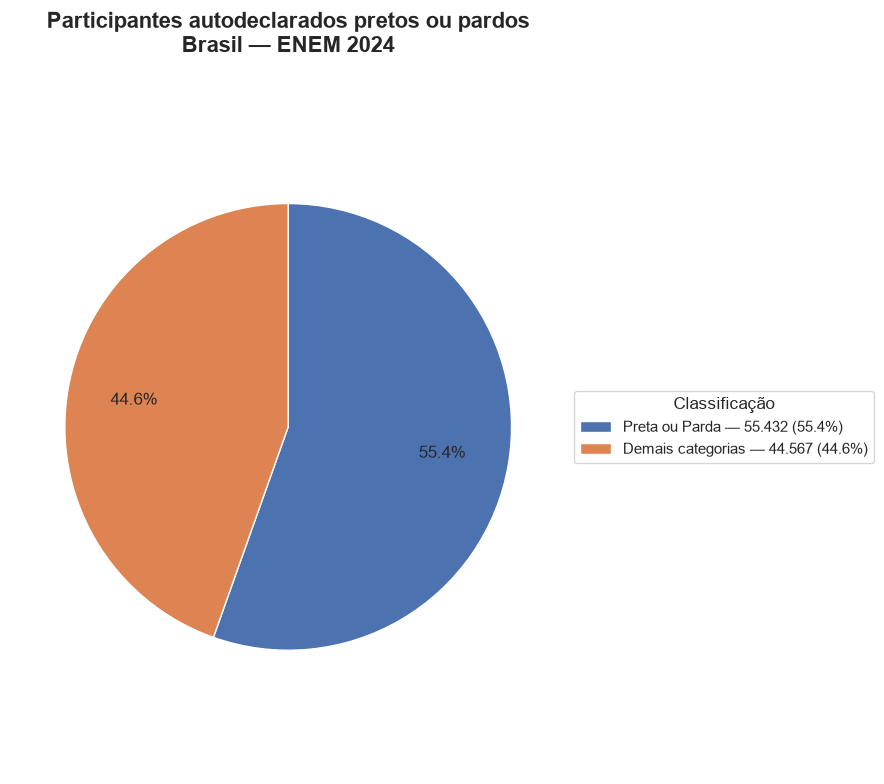

In [49]:
distribuicao_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts()
    .reindex(['Preta ou Parda', 'Demais categorias'])
)

total = distribuicao_negros.sum()

percentuais = distribuicao_negros / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_negros.index,
        distribuicao_negros.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_negros,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes autodeclarados pretos ou pardos\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

## Distribuição por Faixa Etária

In [50]:
df_nacional_amostra['TP_FAIXA_ETARIA'].describe()

count    99999.000000
mean         4.822268
std          3.839890
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         20.000000
Name: TP_FAIXA_ETARIA, dtype: float64

In [51]:
distribuicao_idade = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .value_counts()
    .sort_index()
)

distribuicao_idade

TP_FAIXA_ETARIA
1     11037
2     20107
3     24209
4     10595
5      6163
6      4115
7      3074
8      2345
9      1969
10     1655
11     5403
12     3096
13     2317
14     1646
15     1026
16      669
17      335
18      170
19       49
20       19
Name: count, dtype: int64

In [52]:
percentuais_idade = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

percentuais_idade

TP_FAIXA_ETARIA
1     11.04
2     20.11
3     24.21
4     10.60
5      6.16
6      4.12
7      3.07
8      2.35
9      1.97
10     1.66
11     5.40
12     3.10
13     2.32
14     1.65
15     1.03
16     0.67
17     0.34
18     0.17
19     0.05
20     0.02
Name: proportion, dtype: float64

In [53]:
faixas_etarias = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: '26–30 anos',
    12: '31–35 anos',
    13: '36–40 anos',
    14: '41–45 anos',
    15: '46–50 anos',
    16: '51–55 anos',
    17: '56–60 anos',
    18: '61–65 anos',
    19: '66–70 anos',
    20: 'Maior de 70 anos'
}

df_nacional_amostra['FAIXA_ETARIA'] = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .map(faixas_etarias)
)

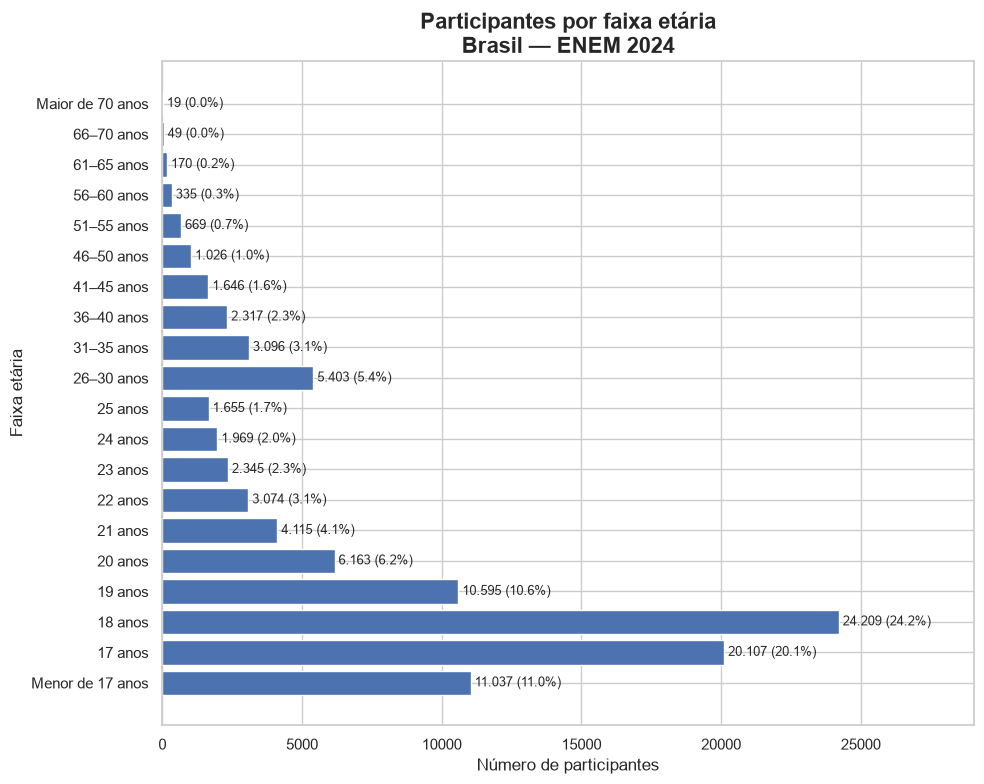

In [54]:
distribuicao_idade = (
    df_nacional_amostra['FAIXA_ETARIA']
    .value_counts()
)

ordem_faixas = list(faixas_etarias.values())

distribuicao_idade = (
    distribuicao_idade
    .reindex(ordem_faixas)
    .dropna()
)

total = distribuicao_idade.sum()

percentuais = (
    distribuicao_idade / total * 100
)

fig, ax = plt.subplots(figsize=(10, 8))

barras = ax.barh(
    distribuicao_idade.index,
    distribuicao_idade.values
)

for barra, valor, percentual in zip(
    barras,
    distribuicao_idade.values,
    percentuais.values
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f' {int(valor):,} ({percentual:.1f}%)'.replace(',', '.'),
        va='center',
        fontsize=9
    )

ax.set_title(
    'Participantes por faixa etária\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes', fontsize=12)
ax.set_ylabel('Faixa etária', fontsize=12)

ax.set_xlim(
    0,
    distribuicao_idade.max() * 1.20
)

plt.tight_layout()
plt.show()